In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
from PIL import Image
import numpy as np

In [23]:
df = pd.read_csv("offense_metrics.csv")
df

,offense_team,avg_pass_score,median_pass_score,avg_open_score,median_open_score,count,I_count,C_count,I_pct,C_pct,pass_pctile,open_pctile
0,ARI,44.349389,51.651019,20.584856,15.927887,436,120,303,27.522936,69.495413,81.250,37.500
1,ATL,38.319365,39.013584,20.733630,16.162647,416,129,274,31.009615,65.865385,15.625,43.750
2,BAL,44.735931,46.395226,22.604614,17.486740,381,110,266,28.871391,69.816273,84.375,78.125
3,BUF,45.230746,52.045669,22.421746,17.745196,450,114,322,25.333333,71.555556,90.625,75.000
4,CAR,43.145753,40.518938,21.738233,16.704412,441,136,297,30.839002,67.346939,68.750,59.375
5,CHI,48.776799,58.569462,24.086733,19.587638,359,91,257,25.348189,71.587744,96.875,93.750
6,CIN,43.402725,50.452561,20.103836,16.780575,460,119,330,25.869565,71.739130,75.000,31.250
7,CLE,40.027710,41.167486,20.915771,16.179938,478,164,297,34.309623,62.133891,34.375,50.000
8,DAL,41.790360,43.697161,19.098321,15.239590,514,134,373,26.070039,72.568093,53.125,15.625
9,DEN,45.005242,53.401702,22.339893,18.300882,376,97,274,25.797872,72.872340,87.500,71.875


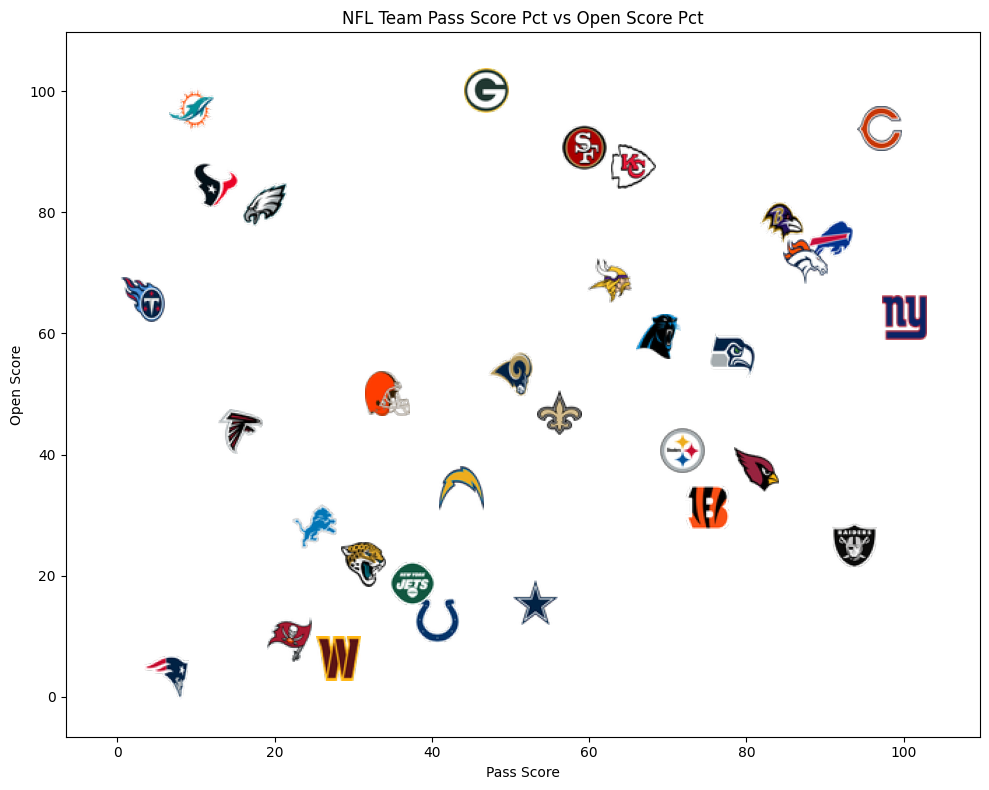

In [24]:
# Target logo size in pixels (same for all teams)
LOGO_SIZE = (32, 32)

fig, ax = plt.subplots(figsize=(10, 8))

# Invisible scatter to set axis limits
ax.scatter(df["pass_pctile"], df["open_pctile"], alpha=0)

for _, row in df.iterrows():
    logo_path = "logos/" + row["offense_team"] + ".png"

    # Load image with PIL
    img = Image.open(logo_path).convert("RGBA")

    # Resize to fixed resolution
    img = img.resize(LOGO_SIZE, Image.Resampling.LANCZOS)

    # Convert to numpy array for matplotlib
    img_arr = np.asarray(img)

    imagebox = OffsetImage(img_arr, zoom=1.0)

    ab = AnnotationBbox(
        imagebox,
        (row["pass_pctile"], row["open_pctile"]),
        frameon=False
    )
    ax.add_artist(ab)

ax.set_xlabel("Pass Score")
ax.set_ylabel("Open Score")
ax.set_title("NFL Team Pass Score Pct vs Open Score Pct")

ax.margins(0.1)
plt.tight_layout()
plt.show()

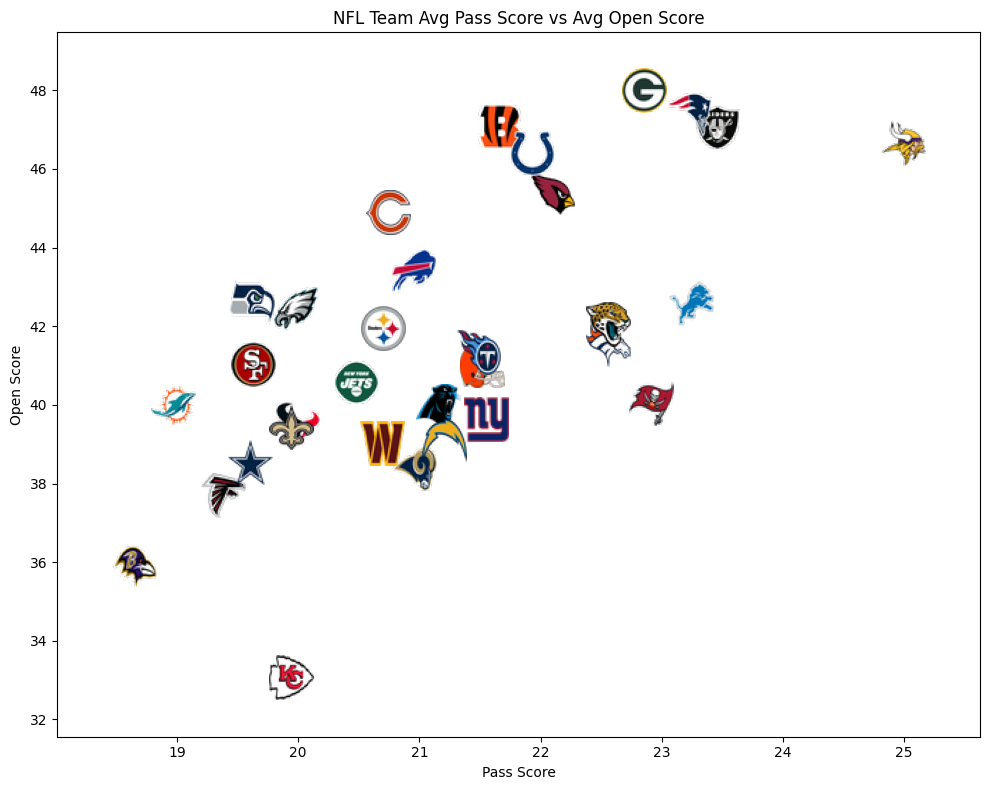

In [22]:
# Target logo size in pixels (same for all teams)
LOGO_SIZE = (32, 32)

fig, ax = plt.subplots(figsize=(10, 8))

# Invisible scatter to set axis limits
ax.scatter(df["avg_open_score"], df["avg_pass_score"], alpha=0)

for _, row in df.iterrows():
    logo_path = "logos/" + row["defense_team"] + ".png"

    # Load image with PIL
    img = Image.open(logo_path).convert("RGBA")

    # Resize to fixed resolution
    img = img.resize(LOGO_SIZE, Image.Resampling.LANCZOS)

    # Convert to numpy array for matplotlib
    img_arr = np.asarray(img)

    imagebox = OffsetImage(img_arr, zoom=1.0)

    ab = AnnotationBbox(
        imagebox,
        (row["avg_open_score"], row["avg_pass_score"]),
        frameon=False
    )
    ax.add_artist(ab)

ax.set_xlabel("Pass Score")
ax.set_ylabel("Open Score")
ax.set_title("NFL Team Avg Pass Score vs Avg Open Score")

ax.margins(0.1)
plt.tight_layout()
plt.show()